# Notebook 03 ML Log Curve Imputation
**AGD 2026 | AI Workflow Engineer**

Goal: Fill missing petrophysical log curves using XGBoost Quantile Regression.
Produces P10/P50/P90 imputed values for uncertainty propagation downstream.

In [1]:
import sys, warnings, yaml
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

with open("../config/settings.yaml") as f:
    CFG = yaml.safe_load(f)

PROC_DIR   = Path("..") / CFG["paths"]["data"]["processed"]
INTER_DIR  = Path("..") / CFG["paths"]["data"]["interim"]
MODEL_DIR  = Path("..") / CFG["paths"]["outputs"]["models"]
FIG_DIR    = Path("..") / CFG["paths"]["outputs"]["figures"]
for d in [INTER_DIR, MODEL_DIR]: d.mkdir(parents=True, exist_ok=True)

from src.models.imputer import LogImputer, run_all_imputers, IMPUTATION_CONFIG

print("Imputation targets:", list(IMPUTATION_CONFIG.keys()))


Imputation targets: ['nphi_vv', 'dt_usft', 'dts_usft', 'rs_ohmm']


## 1. Load merged dataset

In [2]:
df = pd.read_csv(PROC_DIR / "all_wells_merged.csv")
print(f"Loaded: {df.shape}")
print(f"Wells: {df['WELL_ID'].unique()}")
print(f"Rotliegend rows: {df['is_rotliegend'].sum():,}")


Loaded: (99379, 14)
Wells: <StringArray>
['BLT-01', 'EVD-01', 'JUT-01', 'PKP-01']
Length: 4, dtype: str
Rotliegend rows: 10,503


## 2. Before imputation null summary in Rotliegend

In [3]:
target_curves = list(IMPUTATION_CONFIG.keys())
rotl = df[df["is_rotliegend"]]

print("Null % in Rotliegend interval (before imputation):")
null_before = rotl.groupby("WELL_ID")[target_curves].apply(
    lambda g: (100 * g.isna().mean()).round(1)
)
print(null_before.to_string())


Null % in Rotliegend interval (before imputation):
         nphi_vv  dt_usft  dts_usft  rs_ohmm
WELL_ID                                     
BLT-01       0.3     10.1      10.1      2.4
EVD-01     100.0      1.5     100.0    100.0
JUT-01     100.0      0.0     100.0    100.0
PKP-01       0.7      6.9     100.0    100.0


## 3. Run all imputers

In [4]:
df_imputed = run_all_imputers(df, save_dir=MODEL_DIR)
print(f"\nImputed DataFrame shape: {df_imputed.shape}")

# New columns added
new_cols = [c for c in df_imputed.columns if "_imp_" in c or "_final" in c]
print(f"New imputation columns ({len(new_cols)}):")
print(new_cols)



Fitting LogImputer for: nphi_vv
  Neutron Porosity predicted from GR, RHOB, DRHO, TVD
  Features: ['gr_api', 'rhob_gcc', 'drho_gcc', 'TVD_M']
  Training data: 4,711 rows with all curves present


  P50 OOF — MAE: 0.0077, R²: 0.9495



Transforming nphi_vv: 15,233 rows to impute


Imputer saved to ..\outputs\models\nphi_vv_imputer.pkl

Fitting LogImputer for: dt_usft
  Compressional Slowness predicted from GR, RHOB, NPHI, TVD
  Features: ['gr_api', 'rhob_gcc', 'nphi_vv', 'TVD_M']
  Training data: 5,376 rows with all curves present


  P50 OOF — MAE: 1.3957, R²: 0.9029


...


Transforming dts_usft: 24,825 rows to impute


Imputer saved to ..\outputs\models\dts_usft_imputer.pkl

Fitting LogImputer for: rs_ohmm
  Shallow Resistivity predicted from GR, RHOB, NPHI, TVD
  Features: ['gr_api', 'rhob_gcc', 'nphi_vv', 'TVD_M']
  Training data: 2,528 rows with all curves present


  P50 OOF — MAE: 0.3034, R²: 0.9613



Transforming rs_ohmm: 24,340 rows to impute


Imputer saved to ..\outputs\models\rs_ohmm_imputer.pkl

Imputed DataFrame shape: (99379, 30)
New imputation columns (16):
['nphi_vv_imp_p10', 'nphi_vv_imp_p50', 'nphi_vv_imp_p90', 'nphi_vv_final', 'dt_usft_imp_p10', 'dt_usft_imp_p50', 'dt_usft_imp_p90', 'dt_usft_final', 'dts_usft_imp_p10', 'dts_usft_imp_p50', 'dts_usft_imp_p90', 'dts_usft_final', 'rs_ohmm_imp_p10', 'rs_ohmm_imp_p50', 'rs_ohmm_imp_p90', 'rs_ohmm_final']


## 4. After imputation null summary

In [5]:
final_cols = [f"{t}_final" for t in target_curves if f"{t}_final" in df_imputed.columns]
rotl_imp = df_imputed[df_imputed["is_rotliegend"]]

print("Null % in Rotliegend (AFTER imputation — _final columns):")
null_after = rotl_imp.groupby("WELL_ID")[final_cols].apply(
    lambda g: (100 * g.isna().mean()).round(1)
)
print(null_after.to_string())


Null % in Rotliegend (AFTER imputation — _final columns):
         nphi_vv_final  dt_usft_final  dts_usft_final  rs_ohmm_final
WELL_ID                                                             
BLT-01             0.3            3.2             3.2            2.4
EVD-01            75.2            0.6            73.9           75.2
JUT-01           100.0            0.0            89.0          100.0
PKP-01             0.7            1.0             1.0            1.0


## 5. Visualise imputation NPHI example

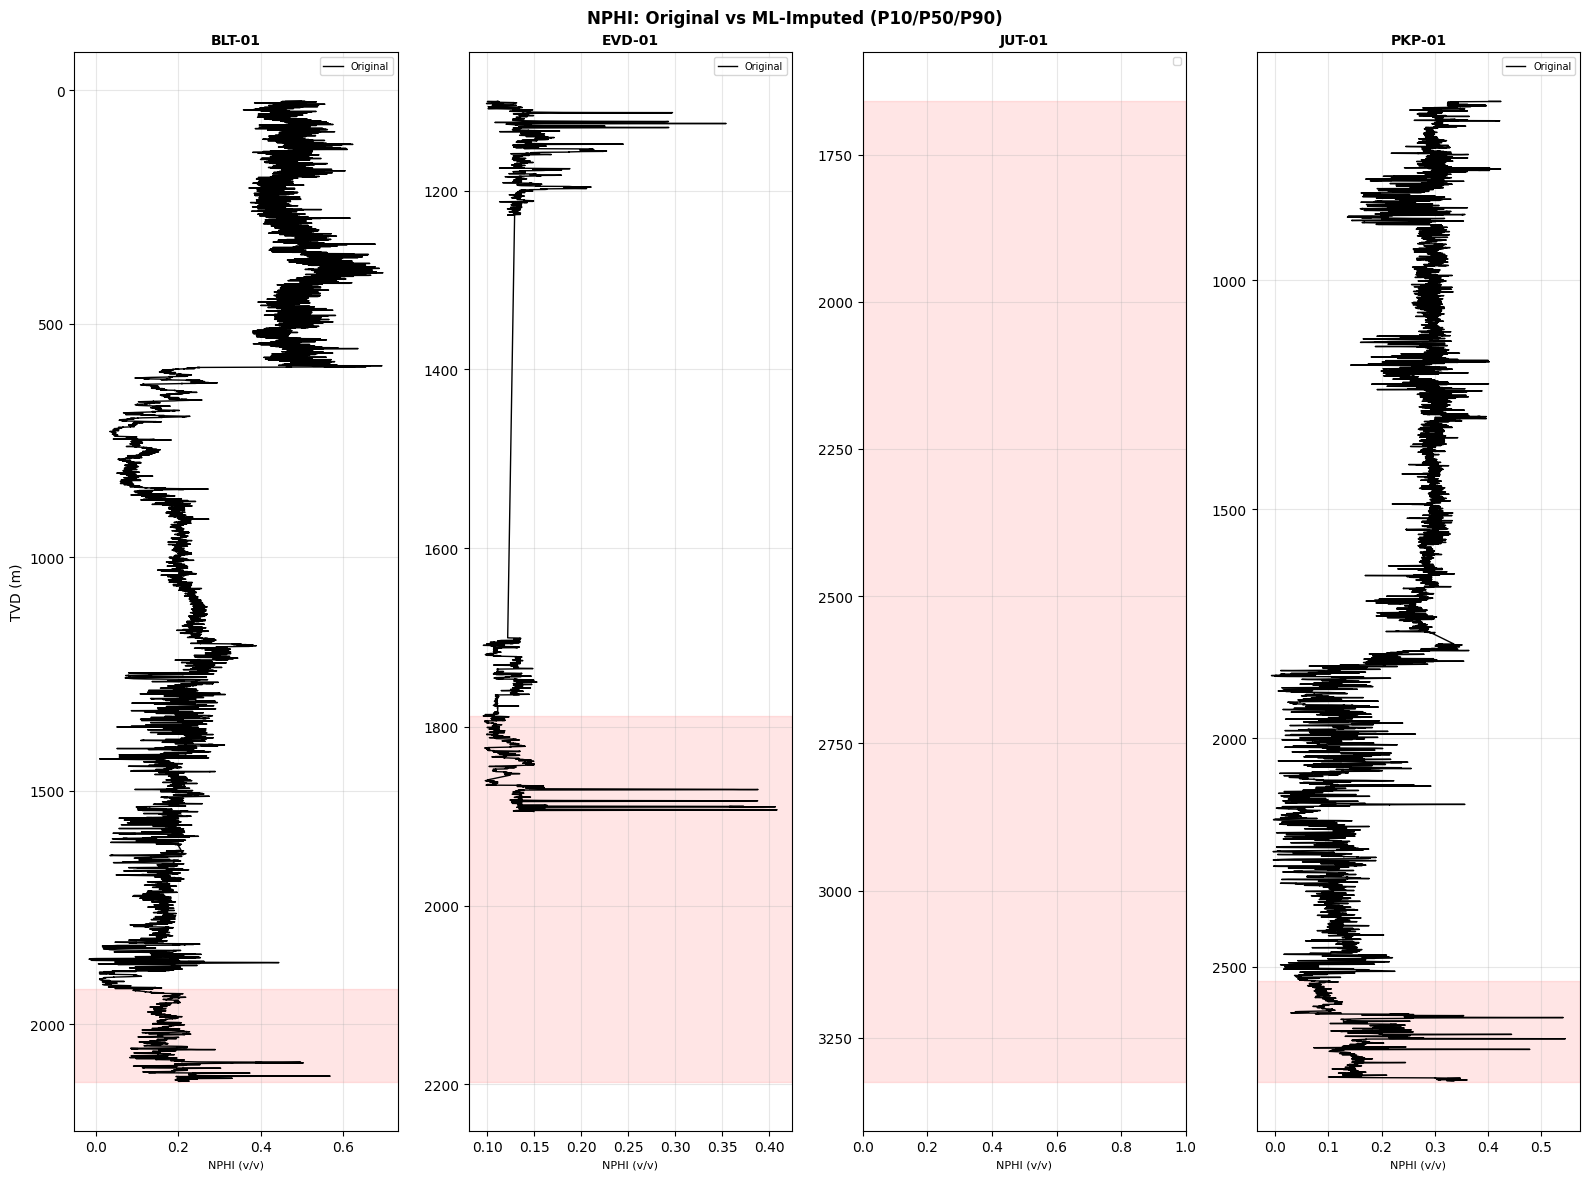

Saved: 03_nphi_imputation.png


In [6]:
fig, axes = plt.subplots(1, len(CFG["wells"]["all"]),
                         figsize=(4 * len(CFG["wells"]["all"]), 12),
                         sharey=False)

target = "nphi_vv"
p50_col  = f"{target}_imp_p50"
p10_col  = f"{target}_imp_p10"
p90_col  = f"{target}_imp_p90"

for ax, well_name in zip(axes, CFG["wells"]["all"]):
    wdf = df_imputed[df_imputed["WELL_ID"] == well_name].sort_values("TVD_M")

    # Original (where not null)
    orig = wdf[wdf[target].notna()]
    if not orig.empty:
        ax.plot(orig[target], orig["TVD_M"],
                color="black", lw=1.0, label="Original", zorder=3)

    # Imputed P50 (where original was null)
    imp_mask = wdf[target].isna() & wdf[p50_col].notna() if p50_col in wdf.columns else pd.Series(False)
    imp_rows = wdf[imp_mask] if hasattr(imp_mask, "__len__") else pd.DataFrame()

    if p50_col in wdf.columns and not imp_rows.empty:
        ax.plot(imp_rows[p50_col], imp_rows["TVD_M"],
                color="blue", lw=1.0, ls="--", label="Imputed P50", zorder=2)
        if p10_col in wdf.columns and p90_col in wdf.columns:
            ax.fill_betweenx(imp_rows["TVD_M"],
                             imp_rows[p10_col], imp_rows[p90_col],
                             alpha=0.2, color="blue", label="P10–P90")

    # Shade Rotliegend
    rotl_wdf = wdf[wdf["is_rotliegend"]]
    if not rotl_wdf.empty:
        ax.axhspan(rotl_wdf["TVD_M"].min(), rotl_wdf["TVD_M"].max(),
                   alpha=0.1, color="red")

    ax.invert_yaxis()
    ax.set_title(well_name, fontsize=10, fontweight="bold")
    ax.set_xlabel("NPHI (v/v)", fontsize=8)
    if well_name == CFG["wells"]["all"][0]:
        ax.set_ylabel("TVD (m)")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("NPHI: Original vs ML-Imputed (P10/P50/P90)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_nphi_imputation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 03_nphi_imputation.png")


## 6. Model metrics summary

In [7]:
# LogImputer metrics are printed during fit — summarise here
print("\nImputation model metrics (OOF cross-validation on P50):")
print("  Metric = MAE and R² on held-out folds")
print("  These were printed above during run_all_imputers().")
print()
print("  Interpretation:")
print("  - MAE for NPHI should be < 0.03 v/v to be useful")
print("  - MAE for DT should be < 5 µs/ft to be useful")
print("  - R² > 0.7 indicates good predictive power")



Imputation model metrics (OOF cross-validation on P50):
  Metric = MAE and R² on held-out folds
  These were printed above during run_all_imputers().

  Interpretation:
  - MAE for NPHI should be < 0.03 v/v to be useful
  - MAE for DT should be < 5 µs/ft to be useful
  - R² > 0.7 indicates good predictive power


## 7. Save imputed output

In [8]:
out_path = INTER_DIR / "all_wells_imputed.csv"
df_imputed.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"Shape: {df_imputed.shape}")
print(f"Columns: {list(df_imputed.columns)}")


Saved: ..\data\interim\all_wells_imputed.csv
Shape: (99379, 30)
Columns: ['WELL_ID', 'DEPTH_M', 'TVD_M', 'gr_api', 'rhob_gcc', 'drho_gcc', 'nphi_vv', 'dt_usft', 'dts_usft', 'rd_ohmm', 'rm_ohmm', 'rs_ohmm', 'formation', 'is_rotliegend', 'nphi_vv_imp_p10', 'nphi_vv_imp_p50', 'nphi_vv_imp_p90', 'nphi_vv_final', 'dt_usft_imp_p10', 'dt_usft_imp_p50', 'dt_usft_imp_p90', 'dt_usft_final', 'dts_usft_imp_p10', 'dts_usft_imp_p50', 'dts_usft_imp_p90', 'dts_usft_final', 'rs_ohmm_imp_p10', 'rs_ohmm_imp_p50', 'rs_ohmm_imp_p90', 'rs_ohmm_final']
